In [1]:
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")

from lib.utils.curve_fitting import fitting
from lib.utils.curve_fitting import gompertz_4p
from lib.utils.curve_fitting import r_squared

In [2]:
# Plot color
cols1 = sns.color_palette("Oranges", 3)
cols2 = sns.color_palette("Greens", 3)

In [3]:
# Load data
data = pd.read_csv("../data/cytotoxicity/2nd-gen_CARs.csv")
data.head()

,id,transduction(lot#1),transduction(lot#2),cytotoxic_activity(lot#1),cytotoxic_activity(lot#2)
0,CAR_28z,42.009440,35.321569,67.455294,25.650750
1,CAR_28z,42.009440,35.321569,60.471486,41.333145
2,CAR_28z,43.844197,27.274300,67.028495,31.868344
3,CAR_28z,43.844197,27.274300,74.277843,37.797207
4,CAR_28z,15.447431,43.056154,45.223173,41.672393


/home/kyoshida/.pyenv/versions/3.10.3/envs/esm2/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


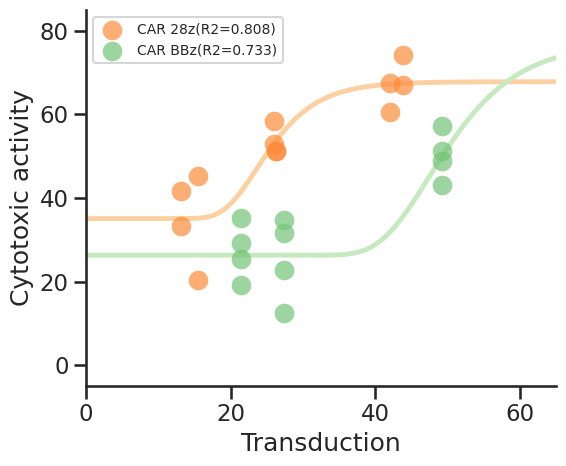

In [4]:
# Plot Donor-1
trans_28z = data[data.id == "CAR_28z"]["transduction(lot#1)"]
cyto_28z = data[data.id == "CAR_28z"]["cytotoxic_activity(lot#1)"]
popt_28z = fitting(trans_28z, cyto_28z, gompertz_4p, p0=[1, 1, 0.01, 10])
r2_28z = r_squared(trans_28z, cyto_28z, popt_28z, gompertz_4p)

trans_BBz = data[data.id == "CAR_BBz"]["transduction(lot#1)"]
cyto_BBz = data[data.id == "CAR_BBz"]["cytotoxic_activity(lot#1)"]
popt_BBz = fitting(trans_BBz, cyto_BBz, gompertz_4p, p0=[0.1, 10, 0.05, 0.05])
r2_BBz = r_squared(trans_BBz, cyto_BBz, popt_BBz, gompertz_4p)

x = np.linspace(0.0, 65, 100)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(x, gompertz_4p(x, *popt_28z), color=cols1[0], zorder=0, linewidth=3.5)
ax.scatter(trans_28z, cyto_28z, color=cols1[1], alpha=0.7, linewidth=0, s=200, label=f"CAR 28z(R2={r2_28z:.3f})")
ax.plot(x, gompertz_4p(x, *popt_BBz), color=cols2[0], zorder=0, linewidth=3.5)
ax.scatter(trans_BBz, cyto_BBz, color=cols2[1], alpha=0.7, linewidth=0, s=200, label=f"CAR BBz(R2={r2_BBz:.3f})")
ax.set_xlim(0, 65)
ax.set_ylim(-5, 85)
ax.set_xlabel("Transduction")
ax.set_ylabel("Cytotoxic activity")
ax.legend(loc="upper left", fontsize=10)
sns.despine()
fig.tight_layout()
fig.savefig("./figures/fitting_curve_donor1.svg")

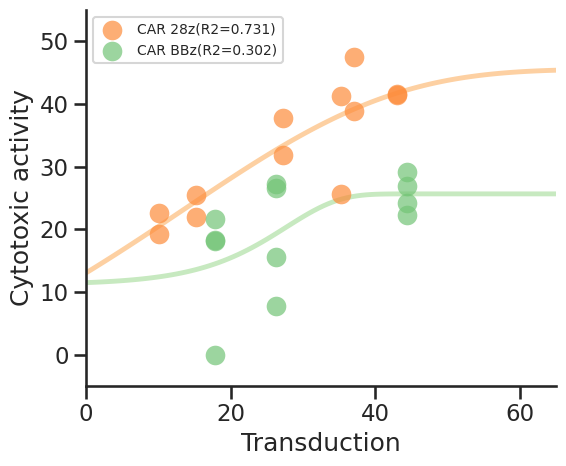

In [5]:
# Plot Donor-2
trans_28z = data[data.id == "CAR_28z"]["transduction(lot#2)"]
cyto_28z = data[data.id == "CAR_28z"]["cytotoxic_activity(lot#2)"]
popt_28z = fitting(trans_28z, cyto_28z, gompertz_4p, p0=[10, 1, 0.01, 10])
r2_28z = r_squared(trans_28z, cyto_28z, popt_28z, gompertz_4p)

trans_BBz = data[data.id == "CAR_BBz"]["transduction(lot#2)"]
cyto_BBz = data[data.id == "CAR_BBz"]["cytotoxic_activity(lot#2)"]
popt_BBz = fitting(trans_BBz, cyto_BBz, gompertz_4p, p0=[10, 1, 0.01, 10])
r2_BBz = r_squared(trans_BBz, cyto_BBz, popt_BBz, gompertz_4p)

x = np.linspace(0.0, 65, 100)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(x, gompertz_4p(x, *popt_28z), color=cols1[0], zorder=0, linewidth=3.5)
ax.scatter(trans_28z, cyto_28z, color=cols1[1], alpha=0.7, linewidth=0, s=200, label=f"CAR 28z(R2={r2_28z:.3f})")
ax.plot(x, gompertz_4p(x, *popt_BBz), color=cols2[0], zorder=0, linewidth=3.5)
ax.scatter(trans_BBz, cyto_BBz, color=cols2[1], alpha=0.7, linewidth=0, s=200, label=f"CAR BBz(R2={r2_BBz:.3f})")
ax.set_xlim(0, 65)
ax.set_ylim(-5, 55)
ax.set_xlabel("Transduction")
ax.set_ylabel("Cytotoxic activity")
ax.legend(loc="upper left", fontsize=10)
sns.despine()
fig.tight_layout()
fig.savefig("./figures/fitting_curve_donor2.svg")